<a href="https://colab.research.google.com/github/tphlabs/Lab4_codesnippets/blob/main/Lab4_Xray_codesnippets.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 4. Characteristic X-Ray radiation from metals

Igor Gitelman, 2024 - 2025, v0.2.1 (UNDER CONSTRUCTION)

In [ ]:
import numpy as np # math functions
import matplotlib.pyplot as plt # for plotting figures and setting their properties
from scipy.signal import find_peaks as find_peaks # Find peaks inside a signal based on peak properties.
from scipy.stats import linregress as linregress #Calculate a linear least-squares regression for two sets of measurements.


## Calibration of the energy detector

This is the typical procedure you can use. You measure a spectrum and save it to a file, like “Mes1.txt”.
Then you can use a code similar to the one below to import and smooth the data, and to plot it.

### Read and smooth the noisy signal from MCA

Defining python function for smooth the noisy `signal` by averaging over running window of size `window_size`, for later use.

In [ ]:
def smooth(signal, window_size):
    box = np.ones(window_size) / window_size
    signal_smoothed = np.convolve(signal, box, mode='same')
    return signal_smoothed

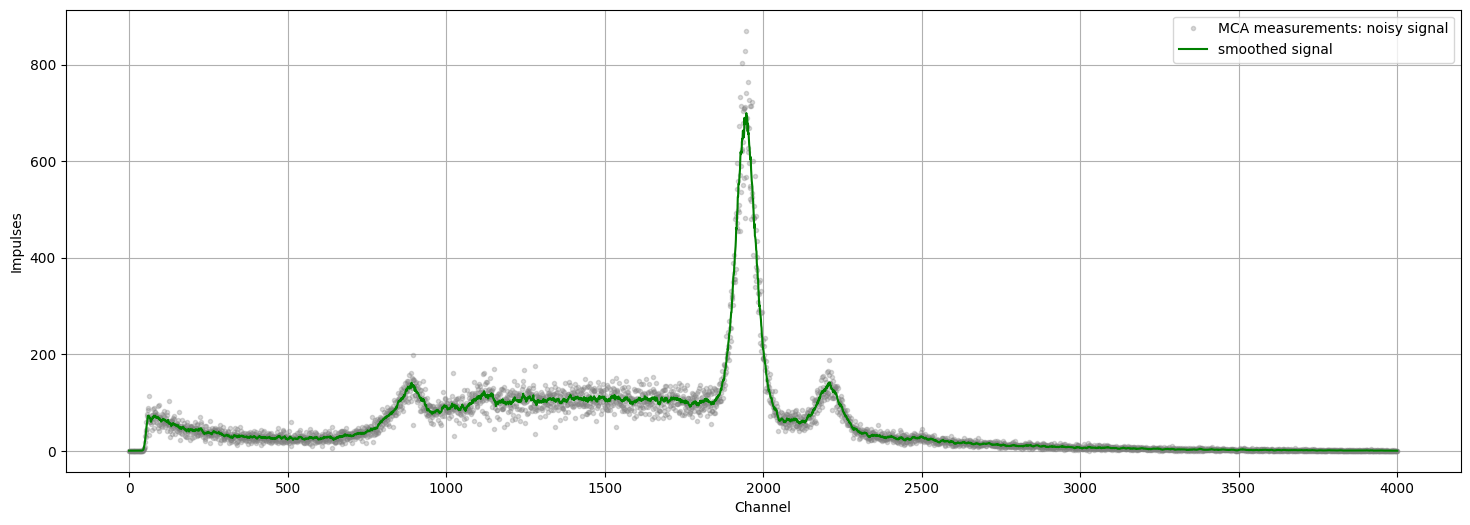

In [ ]:
# place path to your data here
# when using Anaconda UPLOAD files to your localhost
URL = 'https://raw.githubusercontent.com/tphlabs/data/main/Lab4_Xray/Mes1.txt'
channel, signal = np.genfromtxt(URL, delimiter='\t', skip_header=3, unpack=True) # read the data.
signal_smoothed = smooth(signal, 10) # smooth the data over 10 channels
plt.figure(figsize=(18,6))
plt.plot(channel, signal, '.', alpha=0.3, color='gray', label='MCA measurements: noisy signal')
plt.plot(channel, signal_smoothed, '-', color='green', label='smoothed signal')
plt.xlabel('Channel')
plt.ylabel('Impulses')
plt.legend()
plt.grid()


### Identify peaks of pure Molybdenium spectrum

We suggest that the highest peak near channel 1900 is $K_\alpha$ energy of Molybdenium, and the next peak near channel 2200 is $K_\beta$.

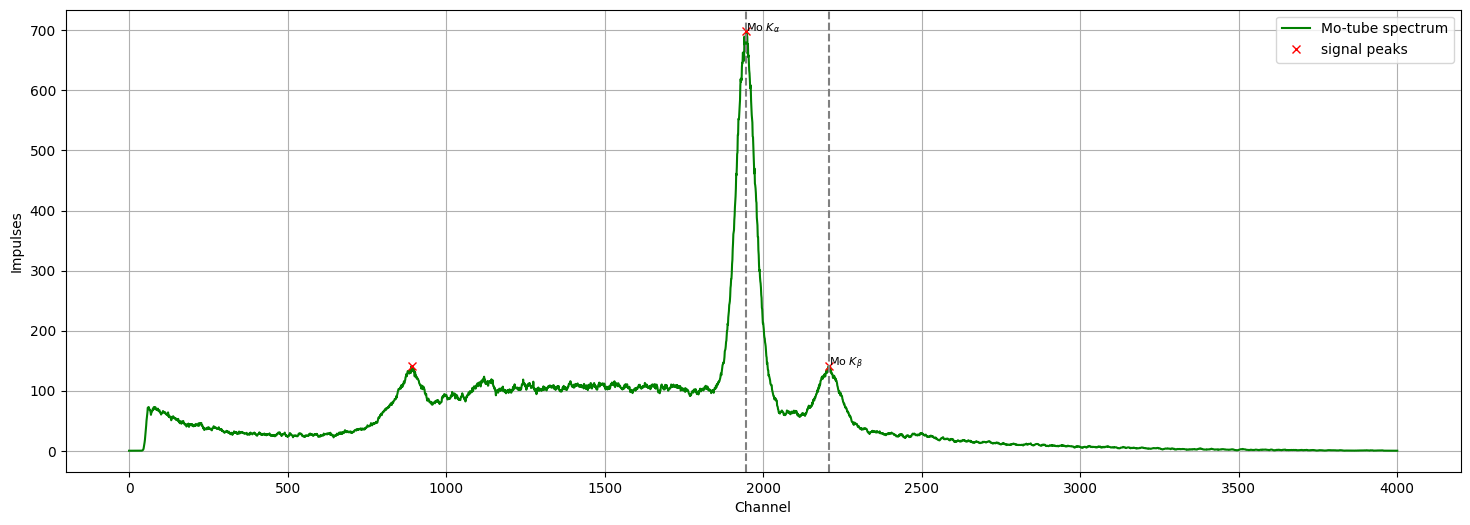

In [ ]:
peaks, _ = find_peaks(signal_smoothed, height=100, prominence=40) # Find the channels where peaks of impulses happen

plt.figure(figsize=(18,6))

# signal
plt.plot(channel, signal_smoothed, '-', color='green', label='Mo-tube spectrum')

# show all peaks
plt.plot(channel[peaks], signal_smoothed[peaks], 'x', color='red', label='signal peaks')

# show identified peaks of Molybdenium
Mo_K_alpha = peaks[1]
plt.axvline(Mo_K_alpha, color='gray', ls='--')
plt.text(Mo_K_alpha, signal_smoothed[Mo_K_alpha], r'Mo $K_{\alpha}$', fontsize=8)

Mo_K_beta = peaks[2]
plt.axvline(Mo_K_beta, color='gray', ls='--')
plt.text(Mo_K_beta, signal_smoothed[Mo_K_beta], r'Mo $K_{\beta}$', fontsize=8)

plt.xlabel('Channel')
plt.ylabel('Impulses')
plt.legend()
plt.grid()



### Finally calibrate: convert from channels to energies

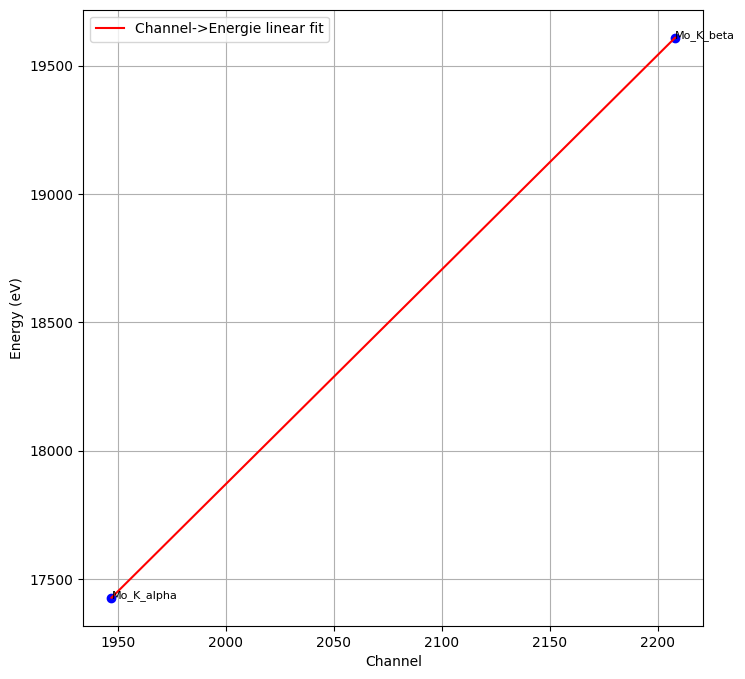

In [ ]:
channel_points = {}
energy_points = {}

channel_points['Mo_K_alpha'] = Mo_K_alpha
channel_points['Mo_K_beta'] = Mo_K_beta
energy_points['Mo_K_alpha'] = (17479.34 + 17374.3) / 2 # eV. K_alpha actually has two close energy levels. Let's suggest that K_alpha is their's average.
energy_points['Mo_K_beta']  = 19608.3 # eV

# you can add to this list charactiristic lines of other known metals
# Zn ..
# Pb ..
# Fe..


# do linear regression fit
x = np.fromiter(channel_points.values(), dtype=float)
y = np.fromiter(energy_points.values(), dtype=float)
fit = linregress(x, y)

# having linear regression fit parameters known with lines identified, we can calculate Energy from Channel
def Channel_to_Energy(ch, fit):
    return fit.slope * ch + fit.intercept

plt.figure(figsize=(8,8))
# show identified characteristics on channel - energy axis
for point in channel_points:
    plt.plot(channel_points[point], energy_points[point], 'o', color='blue')
    plt.text(channel_points[point], energy_points[point], point, fontsize=8)

# plot linear fit line
plt.plot(x, Channel_to_Energy(x, fit), color='red', label='Channel->Energie linear fit')

plt.xlabel('Channel')
plt.ylabel('Energy (eV)')
plt.legend()
plt.grid()



## Analyze alloys and crystals